# Scenario: Fashion Product Image Classifier

You are working as an AI Engineer for an e-commerce company.  
The company wants to automatically classify clothing products from images into categories such as:  
T-shirt  
Trouser  
Pullover  
Dress  
Coat  
Sandal  
Shirt  
Sneaker  
Bag  
Ankle boot  
The dataset contains 28×28 grayscale images of fashion items.  
Your goal is to build a Convolutional Neural Network (CNN) that can classify these fashion products correctly.

In [3]:
from tensorflow.keras.datasets import fashion_mnist
from keras import Sequential
from keras.layers import Conv2D,MaxPooling2D,Flatten,Dense
from keras.utils import to_categorical
import matplotlib.pyplot as plt
import numpy as np

# Task 1 — Dataset Exploration

Load the Fashion-MNIST dataset and perform basic inspection.  
Students must:  
Load dataset using TensorFlow/Keras  
Print:  
Number of training images  
Number of testing images  
Display 10 random images with their labels

In [4]:
#load the dataset
(x_train,y_train),(x_test,y_test)=fashion_mnist.load_data()

#display dataset shapes
print(f"x_train shape: {x_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"x_test shape: {x_test.shape}")
print(f"y_test shape: {y_test.shape}")

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 1s 33us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 111s 4us/step  
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 59us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 2s 1us/step
x_train shape: (60000, 28, 28)
y_train shape: (60000,)
x_test shape: (10000, 28, 28)
y_test shape: (10000,)


In [5]:
class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

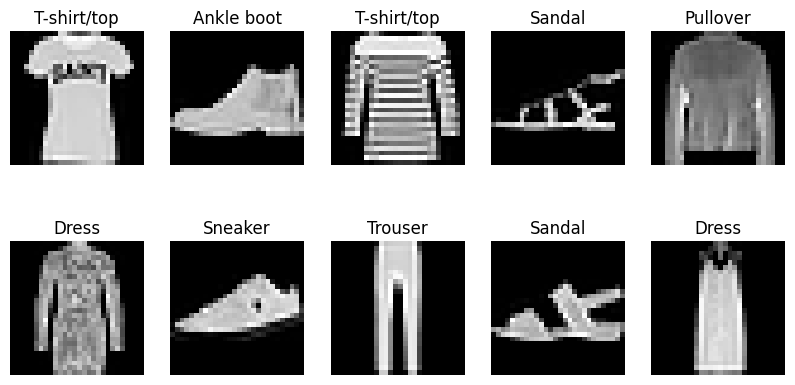

In [8]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))

for i in range(10):
    index = np.random.randint(0, len(x_train))
    
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[index], cmap="gray")
    plt.title(class_names[y_train[index]])
    plt.axis("off")

plt.show()

# Task 2 — Data Preprocessing 

Prepare the dataset for CNN training.  
Students must:  
Normalize pixel values (0–255 → 0–1)  
Reshape images to CNN format  
Expected shape:  
(28, 28, 1)  
Also convert labels to one-hot encoding.

In [9]:
#normalize
x_train = x_train / 255.0
x_test = x_test / 255.0

In [10]:
#reshape
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

print("New shape:", x_train.shape)

New shape: (60000, 28, 28, 1)


In [11]:
from tensorflow.keras.utils import to_categorical

y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# Task 3 — Visualize Class Distribution

Students must:  
Count number of images in each class  
Plot bar chart of class distribution  

In [12]:
counts = np.bincount(np.argmax(y_train, axis=1))

for i in range(len(class_names)):
    print(class_names[i], ":", counts[i])

T-shirt/top : 6000
Trouser : 6000
Pullover : 6000
Dress : 6000
Coat : 6000
Sandal : 6000
Shirt : 6000
Sneaker : 6000
Bag : 6000
Ankle boot : 6000


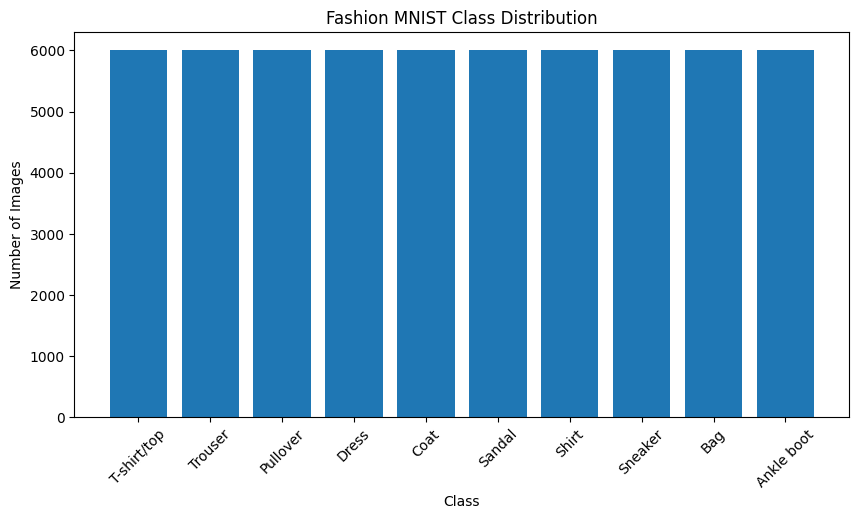

In [13]:
plt.figure(figsize=(10,5))
plt.bar(class_names, counts)
plt.xticks(rotation=45)
plt.title("Fashion MNIST Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.show()

# Task 4 — Build First CNN Architecture

Students must implement a CNN with this architecture:  
Input (28x28x1)  
↓  
Conv2D (32 filters, 3x3)  
↓  
ReLU  
↓  
MaxPooling (2x2)  
↓  
Conv2D (64 filters, 3x3)  
↓  
ReLU  
↓  
MaxPooling (2x2)  
↓  
Flatten  
↓  
Dense (128)  
↓  
Softmax (10)

In [14]:
model=Sequential([
    Conv2D(32,kernel_size=(3,3),activation='relu',input_shape=(28,28,1)), #convolutional layers->detects patterns
    MaxPooling2D(pool_size=(2,2)),#pooling layer->reduces spatial dimensions
    Conv2D(64,kernel_size=(3,3),activation='relu'), #convolutional layers->detects patterns
    MaxPooling2D(pool_size=(2,2)),
    Flatten(),
    Dense(128,activation='relu'),
    Dense(10,activation='softmax')
])
model.summary()

C:\Users\spoor\anaconda3\envs\myenv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 11, 11, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 1600)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         204,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

# Task 5 — Model Compilation

Students must compile the model using:  
Optimizer → Adam  
Loss → categorical crossentropy  
Metrics → accuracy

In [15]:
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

# Task 6 — Train the Model

Train the CNN with:  
Epochs = 10  
Batch size = 64  
Validation split = 20%  
Students must:  
Plot training accuracy vs validation accuracy  
Plot training loss vs validation loss

In [16]:
history=model.fit(x_train,y_train,epochs=10,batch_size=64,validation_split=0.2)
#epochs-> model sees dataset 10 items
#batch_size->processes 64 images per step
#validation_split->uses 20% of training data for validation

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 29s 35ms/step - accuracy: 0.8139 - loss: 0.5117 - val_accuracy: 0.8707 - val_loss: 0.3645
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 40s 34ms/step - accuracy: 0.8798 - loss: 0.3347 - val_accuracy: 0.8825 - val_loss: 0.3205
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 41s 35ms/step - accuracy: 0.8951 - loss: 0.2875 - val_accuracy: 0.8963 - val_loss: 0.2876
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 27s 36ms/step - accuracy: 0.9056 - loss: 0.2562 - val_accuracy: 0.9025 - val_loss: 0.2711
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 28s 37ms/step - accuracy: 0.9139 - loss: 0.2330 - val_accuracy: 0.8957 - val_loss: 0.2886
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 28s 37ms/step - accuracy: 0.9219 - loss: 0.2098 - val_accuracy: 0.9087 - val_loss: 0.2518
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 27s 35ms/step - accuracy: 0.9288 - loss: 0.1919 - val_accuracy: 0.9100 - val_loss: 0.2489
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 27s 35ms/step - accuracy: 0.9353 - loss: 0.1739 - 

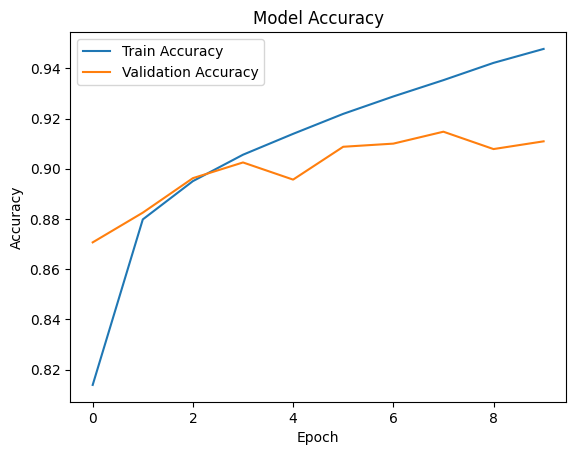

In [18]:
plt.figure()

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")

plt.legend(["Train Accuracy","Validation Accuracy"])

plt.show()

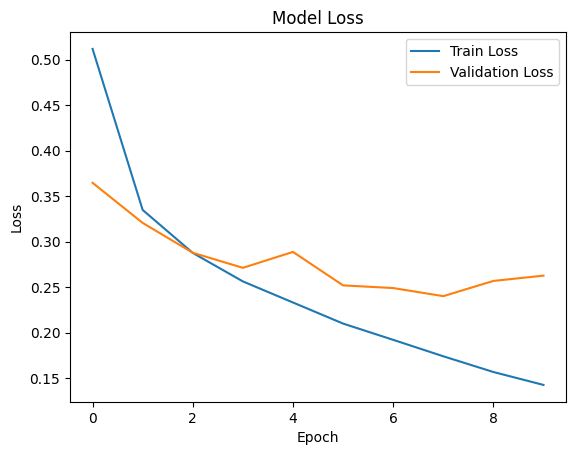

In [19]:
plt.figure()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Model Loss")
plt.ylabel("Loss")
plt.xlabel("Epoch")

plt.legend(["Train Loss","Validation Loss"])

plt.show()

# Task 7 — Model Evaluation
   
Evaluate model performance on test dataset.  
Students must print:  
Test accuracy  
Test loss  
Then display 5 test images with predictions.  


In [17]:
test_loss,test_accuracy=model.evaluate(x_test,y_test)
print(f"Test loss: {test_loss}")
print(f"Test accuracy: {test_accuracy}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9074 - loss: 0.2711
Test loss: 0.2711052894592285
Test accuracy: 0.9074000120162964


In [20]:
predictions = model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step


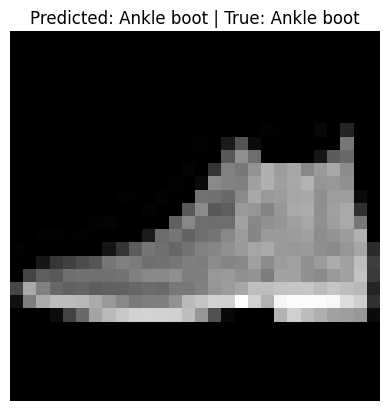

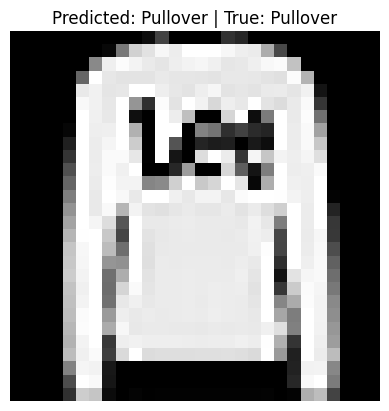

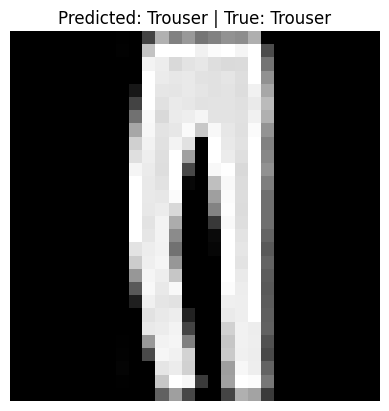

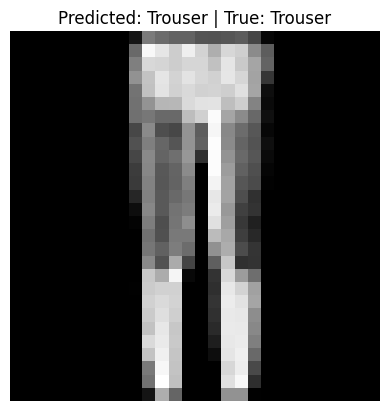

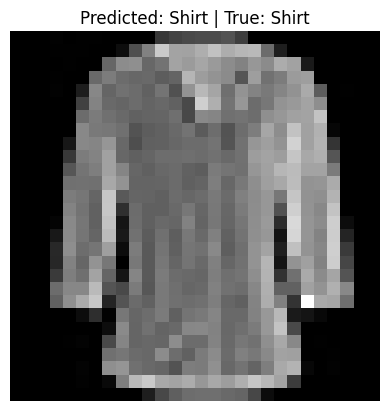

In [24]:
# Predict on first 5 test samples
predictions = model.predict(x_test[:5])
predicted_classes = np.argmax(predictions, axis=1)
true_classes = np.argmax(y_test[:5], axis=1)

for i in range(5):
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.title(f"Predicted: {class_names[predicted_classes[i]]} | True: {class_names[true_classes[i]]}")
    plt.axis("off")
    plt.show()

# Task 8 — Confusion Matrix Analysis

Students must:  
Generate confusion matrix  
Visualize using heatmap  
Goal:  
Understand which classes are misclassified.  
Example challenge:  
Shirt vs T-shirt  
Sneaker vs Ankle Boot  
These are commonly confused.

In [25]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

In [26]:
y_pred = model.predict(x_test)

y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


In [27]:
cm = confusion_matrix(y_true, y_pred_classes)

print(cm)

[[836   0  14  10   2   1 131   0   6   0]
 [  4 983   1   7   1   0   4   0   0   0]
 [ 16   0 852   6  60   0  66   0   0   0]
 [ 28  10   8 890  24   0  36   0   4   0]
 [  2   0  41  21 886   0  47   0   3   0]
 [  0   0   0   0   0 949   0  42   0   9]
 [ 92   0  43  21  76   0 765   0   3   0]
 [  0   0   0   0   0   3   0 980   0  17]
 [  4   0   3   4   2   2   6   6 973   0]
 [  1   0   0   0   0   4   0  35   0 960]]


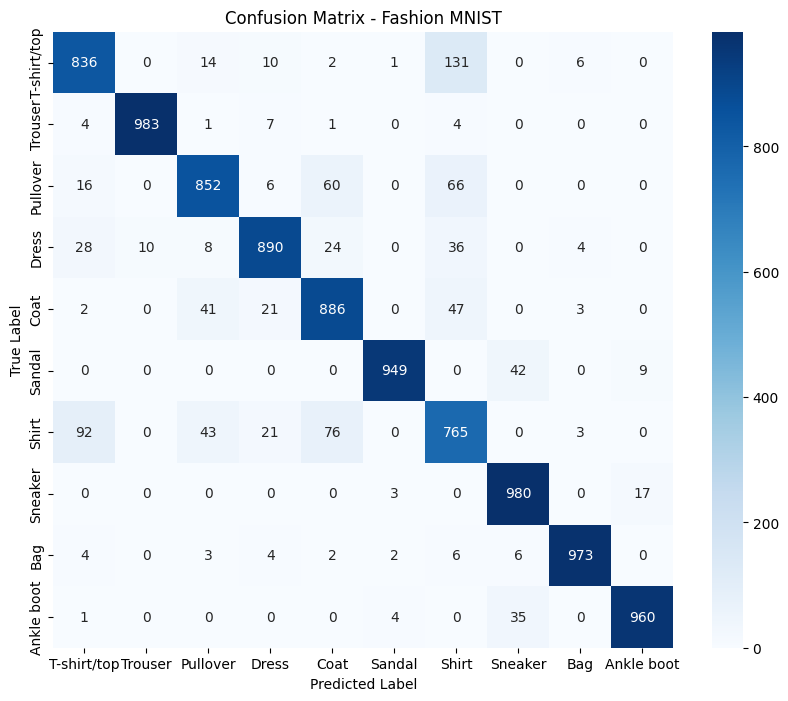

In [28]:
plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Fashion MNIST")

plt.show()

# Task 9 — Improve the CNN Architecture

Students must modify the architecture by:  
Adding Dropout layer  
Increasing filters  
Adding another convolution layer  
Example:  
Conv → Conv → Pool → Conv → Pool  
Then compare:  
Model 1 accuracy vs Model 2 accuracy  
Goal:
Understand model improvement strategies.

In [30]:
from tensorflow.keras.layers import  Dropout

model2 = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D((2,2)),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

In [31]:
model2.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [33]:
history2 = model2.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 44s 53ms/step - accuracy: 0.7785 - loss: 0.6182 - val_accuracy: 0.8485 - val_loss: 0.3972
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 39s 52ms/step - accuracy: 0.8613 - loss: 0.3899 - val_accuracy: 0.8850 - val_loss: 0.3010
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 40s 53ms/step - accuracy: 0.8829 - loss: 0.3271 - val_accuracy: 0.8974 - val_loss: 0.2821
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 41s 52ms/step - accuracy: 0.8925 - loss: 0.2979 - val_accuracy: 0.9067 - val_loss: 0.2515
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 38s 50ms/step - accuracy: 0.9023 - loss: 0.2710 - val_accuracy: 0.9082 - val_loss: 0.2459
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 38s 51ms/step - accuracy: 0.9077 - loss: 0.2512 - val_accuracy: 0.9098 - val_loss: 0.2385
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 39s 52ms/step - accuracy: 0.9149 - loss: 0.2325 - val_accuracy: 0.9120 - val_loss: 0.2464
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 40s 53ms/step - accuracy: 0.9198 - loss: 0.2164 - 

In [35]:
test_loss2, test_accuracy2 = model2.evaluate(x_test, y_test)

print("Improved Model Test Accuracy:", test_accuracy2)
print("Improved Model Test Loss:", test_loss2)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9150 - loss: 0.2402
Improved Model Test Accuracy: 0.9150000214576721
Improved Model Test Loss: 0.24019651114940643


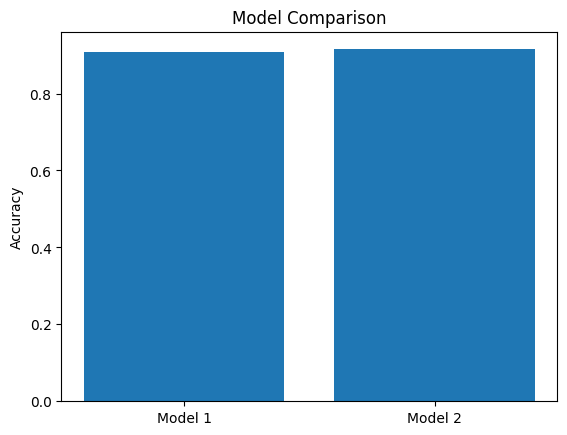

In [36]:
models = ['Model 1','Model 2']
accuracy = [test_accuracy, test_accuracy2]

plt.bar(models, accuracy)
plt.ylabel("Accuracy")
plt.title("Model Comparison")
plt.show()

# Task 10 — Misclassification Analysis

Students must:  
Identify 5 wrongly predicted images  
Display:  
Actual label  
Predicted label  
Then explain:  
Why might the model confuse these classes?  
Goal:  
Develop model debugging skills.

In [37]:
predictions = model.predict(x_test)

predicted_classes = np.argmax(predictions, axis=1)
true_classes = np.argmax(y_test, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step


In [38]:
misclassified = np.where(predicted_classes != true_classes)[0]

print("Total misclassified images:", len(misclassified))

Total misclassified images: 926


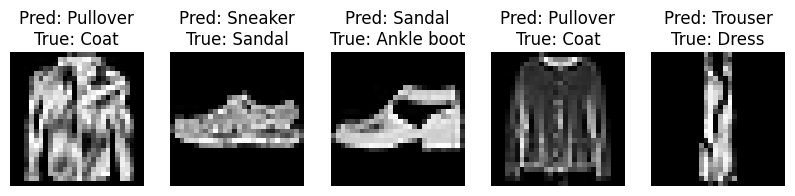

In [40]:
plt.figure(figsize=(10,4))
for i in range(5):
    index = misclassified[i]
    plt.subplot(1,5,i+1)
    plt.imshow(x_test[index].reshape(28,28), cmap='gray')
    plt.title(f"Pred: {class_names[predicted_classes[index]]}\nTrue: {class_names[true_classes[index]]}")
    plt.axis("off")
plt.show()

# Task 11 — Feature Map Visualization 

Students must:  
Extract intermediate CNN layer outputs  
Visualize feature maps for one image  
Goal:  
Understand what CNN learns internally.

In [41]:
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model

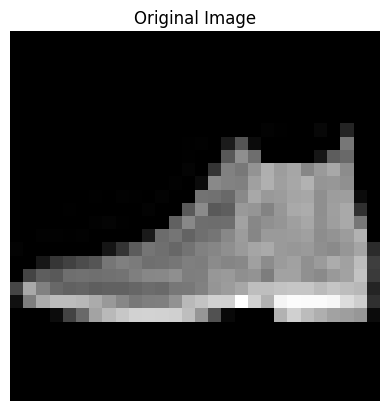

In [43]:
image = x_test[0]

plt.imshow(image.reshape(28,28), cmap="gray")
plt.title("Original Image")
plt.axis("off")
plt.show()

In [45]:
layer_outputs = [layer.output for layer in model.layers if "conv" in layer.name]

feature_model = Model(inputs=model.inputs, outputs=layer_outputs)

In [46]:
feature_maps = feature_model.predict(image.reshape(1,28,28,1))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step


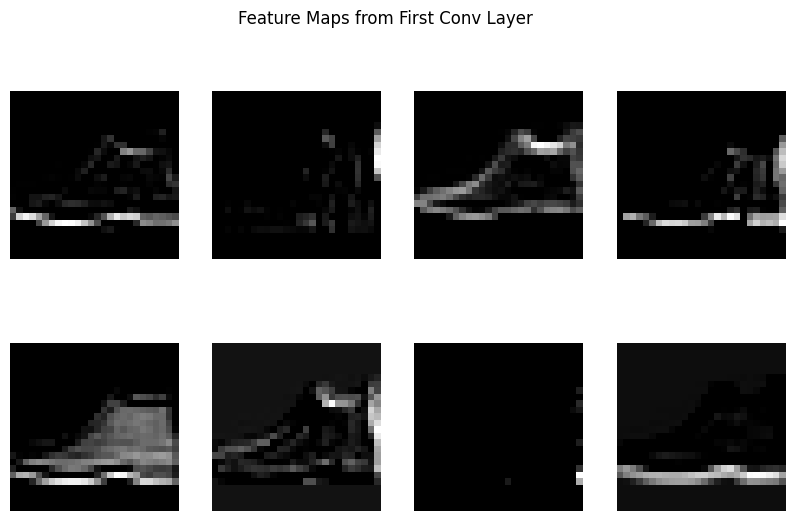

In [47]:
feature_map = feature_maps[0]

plt.figure(figsize=(10,6))

for i in range(8):   # display first 8 filters
    plt.subplot(2,4,i+1)
    plt.imshow(feature_map[0,:,:,i], cmap='gray')
    plt.axis("off")

plt.suptitle("Feature Maps from First Conv Layer")
plt.show()

#  Task 12 — Build Simple Prediction Interface  
Students must write code that:  
Takes a random test image  
Predicts class  
Displays predicted label with probability  
Goal:  
Simulate real-world inference.

In [50]:

index = np.random.randint(0, len(x_test))
image = x_test[index]
true_label = np.argmax(y_test[index])

In [51]:
prediction = model.predict(image.reshape(1,28,28,1))

predicted_class = np.argmax(prediction)
probability = np.max(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step


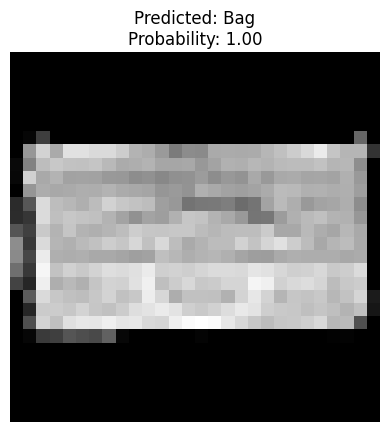

In [52]:
plt.imshow(image.reshape(28,28), cmap="gray")

plt.title(f"Predicted: {class_names[predicted_class]}\nProbability: {probability:.2f}")

plt.axis("off")
plt.show()